# 02. FLIR Termal Veri Ön İşleme ve DataLoader Pipeline

Bu çalışma; kırpılan termal hedef görsellerini derin öğrenme mimarilerinin standart girdi boyutu olan $224 \times 224$ çözünürlüğüne ve tensör formatına dönüştürür. Termal piksel dağılımlarını korumak için renk manipülasyonu yerine yalnızca geometrik veri artırımı uygulanır ve PyTorch DataLoader altyapısı kurulur.

In [8]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Veri yolları
DATA_DIR = "../dataset/raw"
train_dir = os.path.join(DATA_DIR, 'train')
val_dir = os.path.join(DATA_DIR, 'validation')

# Termal Dönüşüm Pipeline'ı
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
}

### Dönüşüm Stratejisi Değerlendirmesi
Görseller $224 \times 224$ piksel boyutuna getirilerek önceden eğitilmiş omurgaların girdi katmanına uyumlu hale getirilmiştir. Termal ısı izlerinde renk bilgisi bulunmadığı için parlaklık/kontrast bozulmalarından kaçınılmış, yalnızca hedefin geliş açısını simüle eden yatay çevirme ve hafif rotasyon ($\pm 10^\circ$) uygulanmıştır. Tek kanallı gri görüntüler PyTorch tarafından 3 kanala çoğaltılarak ImageNet ortalama ve varyans katsayıları ile normalize edilmiştir.

In [9]:
# ImageFolder ile veri yükleme
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms['val'])

# Mini-batch DataLoader tanımları
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Sınıf İndeksleri:", train_dataset.class_to_idx)
print(f"Eğitim Seti: {len(train_dataset)} görsel | {len(train_loader)} batch")
print(f"Doğrulama Seti: {len(val_dataset)} görsel | {len(val_loader)} batch")

Sınıf İndeksleri: {'car': 0, 'person': 1}
Eğitim Seti: 35862 görsel | 1121 batch
Doğrulama Seti: 7287 görsel | 228 batch


c:\Users\sibel\source\repos\AeroVision-ATR\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch Girdi Tensörü: torch.Size([32, 3, 224, 224]) -> [Batch, Kanal, Yükseklik, Genişlik]
Batch Etiket Tensörü: torch.Size([32])


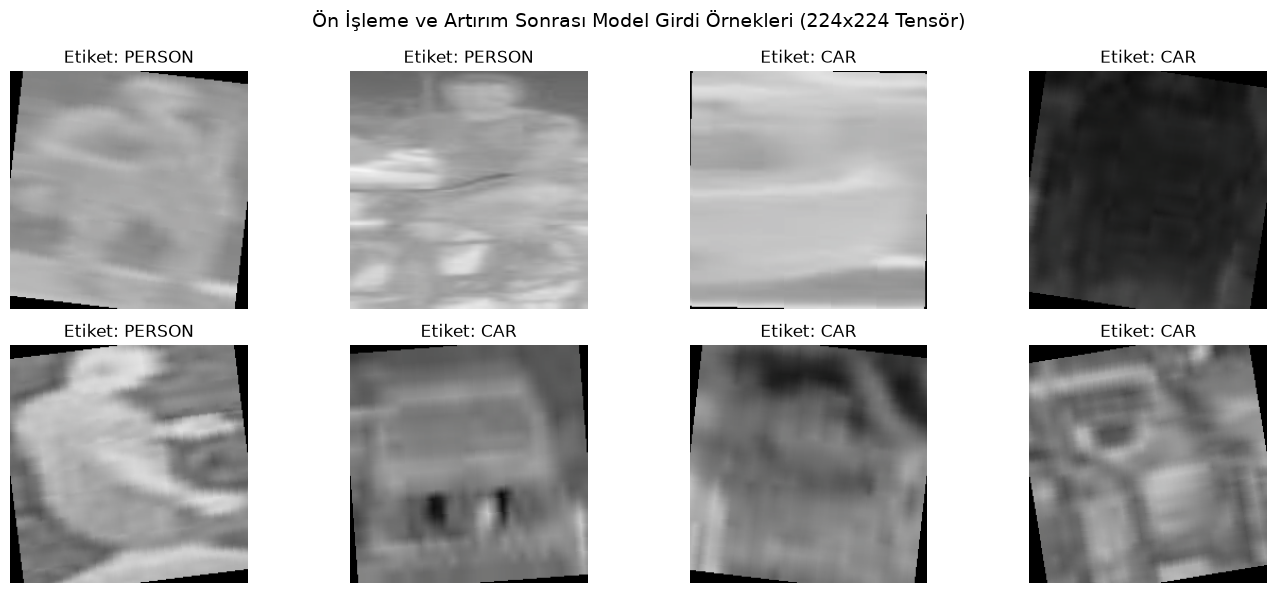

In [10]:
# İlk batch'i çekme
images, labels = next(iter(train_loader))
print(f"Batch Girdi Tensörü: {images.shape} -> [Batch, Kanal, Yükseklik, Genişlik]")
print(f"Batch Etiket Tensörü: {labels.shape}")

# Normalizasyonu geri alma fonksiyonu
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

for i in range(8):
    ax = axes[i // 4, i % 4]
    img = inv_normalize(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(f"Etiket: {idx_to_class[labels[i].item()].upper()}")
    ax.axis('off')

plt.suptitle("Ön İşleme ve Artırım Sonrası Model Girdi Örnekleri (224x224 Tensör)", fontsize=14)
plt.tight_layout()
plt.show()

### Ön İşleme Doğrulama Notu
Tensör boyutlarının `[32, 3, 224, 224]` formatında üretildiği ve sınıfların doğru indekslendiği (`car: 0`, `person: 1`) teyit edilmiştir. Veri akışı, model eğitim adımlarında sıfır gecikmeyle çalışacak şekilde hazır durumdadır.